In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter
import pandas as pd
import scipy.optimize
import math
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, math.sqrt(variance))


path = '/Volumes/Elements/PTM_project/FLNC24/METAD/DATA_PLUMED/'

/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:37: RuntimeWarning: divide by zero encountered in log


<Figure size 288x216 with 0 Axes>

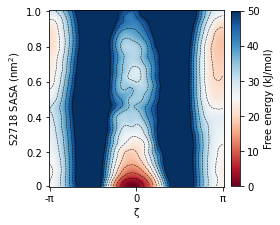

In [7]:
# convergence with rbias reweighting BF15

nsims=3
T = 298

t= 1000
t_discard = 200

h_dat = []
for sim in range(1,nsims+1):
    data = np.loadtxt(path+'COLVAR.{}'.format(sim))
    zeta = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasaSER2718_{}.xvg'.format(sim),skiprows=25)[:,2]
    rbias = data[:,3]

    xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
    yedges = np.arange(0,1.01,0.01)

    frame = int(t*1000/5)
    init_frame = int(t_discard*1000/5)

    # FEL rbias reweighting
    kbt = 0.008314*T

    


    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)

    x=zeta[init_frame:frame]
    y=SASA[init_frame:frame]

    H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
    H = gaussian_filter(H, sigma=2)
    h = H/np.sum(H) # convert counts to probility
    h = -kbt*np.log(h) # calculate free energy from probability
    h = h-np.min(h) # set minimum to 0 kbT
    h = h.T
    h_dat.append(h)

h_dat = np.array(h_dat)
h_mu = np.mean(h_dat,axis=0)
h_err = np.std(h_dat,axis=0)/np.sqrt(nsims)
h_mu = np.nan_to_num(h_mu,posinf=100)

plt.figure(figsize = (4,3))
max_energy = 50
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h_mu, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='RdBu')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-\u03C0',0,'\u03C0']
ylabels = [0,0.2,0.4,0.6,0.8,1.0]
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,19,39,59,79,99],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))
#plt.title('Average')
plt.xlabel('\u03B6')
plt.ylabel('S2718 SASA (nm$^{2}$)')

plt.tight_layout()
plt.savefig('Avg_2D_zeta_vs_SASA.pdf')

/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:37: RuntimeWarning: divide by zero encountered in log


<Figure size 288x216 with 0 Axes>

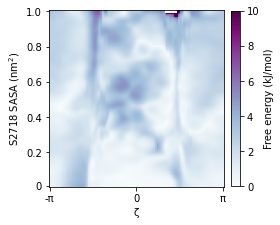

In [14]:
# convergence with rbias reweighting BF15

nsims=3
T = 298

t= 1000
t_discard = 200

h_dat = []
for sim in range(1,nsims+1):
    data = np.loadtxt(path+'COLVAR.{}'.format(sim))
    zeta = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasaSER2718_{}.xvg'.format(sim),skiprows=25)[:,2]
    rbias = data[:,3]

    xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
    yedges = np.arange(0,1.01,0.01)

    frame = int(t*1000/5)
    init_frame = int(t_discard*1000/5)

    # FEL rbias reweighting
    kbt = 0.008314*T

    


    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)

    x=zeta[init_frame:frame]
    y=SASA[init_frame:frame]

    H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
    H = gaussian_filter(H, sigma=2)
    h = H/np.sum(H) # convert counts to probility
    h = -kbt*np.log(h) # calculate free energy from probability
    h = h-np.min(h) # set minimum to 0 kbT
    h = h.T
    h_dat.append(h)

h_dat = np.array(h_dat)
h_mu = np.mean(h_dat,axis=0)
h_err = np.std(h_dat,axis=0)/np.sqrt(nsims)
h_mu = np.nan_to_num(h_mu,posinf=100)

plt.figure(figsize = (4,3))
max_energy = 10
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h_err, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='BuPu')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-\u03C0',0,'\u03C0']
ylabels = [0,0.2,0.4,0.6,0.8,1.0]
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,19,39,59,79,99],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

#plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                #linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))
#plt.title('Average')
plt.xlabel('\u03B6')
plt.ylabel('S2718 SASA (nm$^{2}$)')

plt.tight_layout()
plt.savefig('Err_2D_zeta_vs_SASA.pdf')

In [15]:
# calculate average SASA in cis and in trans state
# calculate average fraction cis

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


cis_SASA = []
trans_SASA = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'COLVAR.{}'.format(s))
    CV = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasaSER2718_{}.xvg'.format(s),skiprows=25)[:,2]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[init_frame:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    transframes = np.where(np.abs(CV[init_frame:frame])>1.4)[0] # abs zeta angle more than ~80 deg
    
    cis_SASA.append(np.average(SASA[init_frame:frame][cisframes],weights=weights[cisframes]))
    trans_SASA.append(np.average(SASA[init_frame:frame][transframes],weights=weights[transframes]))
    
# average and error

mu_cis = np.round(np.mean(cis_SASA),2)
err_cis = np.round(np.std(cis_SASA)/np.sqrt(nsims),2)

mu_trans = np.round(np.mean(trans_SASA),2)
err_trans = np.round(np.std(trans_SASA)/np.sqrt(nsims),2)

df = pd.DataFrame()
df['Proline state'] = ['cis','trans']
df['Avg SASA (nm^2)'] = [mu_cis,mu_trans]
df['Error']  = [err_cis,err_trans]
df.to_csv('avg_SASA_proline_states.csv')
df

,Proline state,Avg SASA (nm^2),Error
0,cis,0.01,0.00
1,trans,0.62,0.09


In [16]:
cis_SASA

[0.010363977189807718, 0.008446778973967993, 0.0079343378201476]

In [17]:
trans_SASA

[0.6966941085613244, 0.4063736023783189, 0.7513622628340036]

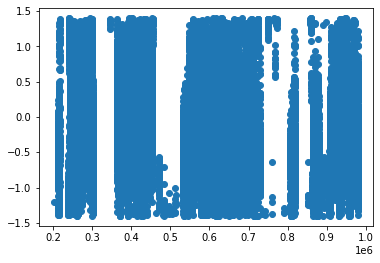

In [18]:
plt.scatter(data[:,0][init_frame:frame][cisframes],CV[init_frame:frame][cisframes])

In [19]:
CV[cisframes]

array([-0.158133, -0.388195, -0.559782, ...,  2.782793, -2.668795,
       -2.983388])

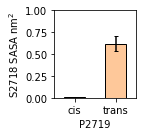

In [22]:
# plot
df = pd.read_csv('avg_SASA_proline_states.csv')
df.plot(x='Proline state',y='Avg SASA (nm^2)',yerr= np.array(df['Error']),
       kind='bar',figsize = (2,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,1)
plt.xlabel('P2719')

plt.ylabel('S2718 SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('S2718_SASA_proline_states_barplot.pdf')